In [77]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [78]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [79]:
# download the dataset

path = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

# read the dataset
text = open(path, 'r', encoding='utf-8').read()


In [80]:
# convert the text to lowercase
text = text.lower()

# print first 500 characters of the text
print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [81]:
# Total number of characters in the text

print(f'Total number of characters in the text: {len(text)}') 

# total number of words in the text
print(f'Total number of words in the text: {len(text.split())}')

Total number of characters in the text: 1115394
Total number of words in the text: 202651


In [82]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1
print(f'Vocabulary Size: {vocab_size}')

Vocabulary Size: 12633


In [83]:
# 1st 10 words

for word, index in list(word_index.items())[:10]:
    print(f'{word}: {index}')

the: 1
and: 2
to: 3
i: 4
of: 5
you: 6
my: 7
a: 8
that: 9
in: 10


In [84]:
# convert the text to sequences of integers
sequences = tokenizer.texts_to_sequences([text])[0]
print(f'First 10 sequences: {sequences[:10]}')


First 10 sequences: [88, 269, 139, 35, 969, 143, 668, 127, 15, 102]


In [85]:
# split text into lines
lines = text.split('\n')

input_sequences = []

for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f'Total number of input sequences: {len(input_sequences)}')

Total number of input sequences: 171312


In [86]:
# find the maximum sequence length
max_sequence_len = max([len(seq) for seq in input_sequences])
print(f'Maximum sequence length: {max_sequence_len}')

Maximum sequence length: 16


In [87]:
# apply padding to the input sequences

input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
print('sequences and words per sequence:', input_sequences.shape)

sequences and words per sequence: (171312, 16)


In [88]:
# split into X and y

X = input_sequences[:,:-1]
y = input_sequences[:,-1]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (171312, 15)
y shape: (171312,)


In [89]:
# convert output into categorical

y = keras.utils.to_categorical(y, num_classes=vocab_size)

In [90]:
# apply LSTM
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()

# add first layer as embedding layer
model.add(Embedding(vocab_size, 10, input_length=max_sequence_len-1))

# add LSTM layer
model.add(LSTM(100))

# add output layer
model.add(Dense(vocab_size, activation='softmax'))


c:\Users\sumit\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [91]:
# model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [92]:
# compile the model

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [93]:
# train the model
history = model.fit(X, y, epochs=2, verbose=1)

Epoch 1/2
5354/5354 ━━━━━━━━━━━━━━━━━━━━ 128s 23ms/step - accuracy: 0.0393 - loss: 6.8540
Epoch 2/2
5354/5354 ━━━━━━━━━━━━━━━━━━━━ 124s 23ms/step - accuracy: 0.0658 - loss: 6.3478


KeyError: 'val_accuracy'

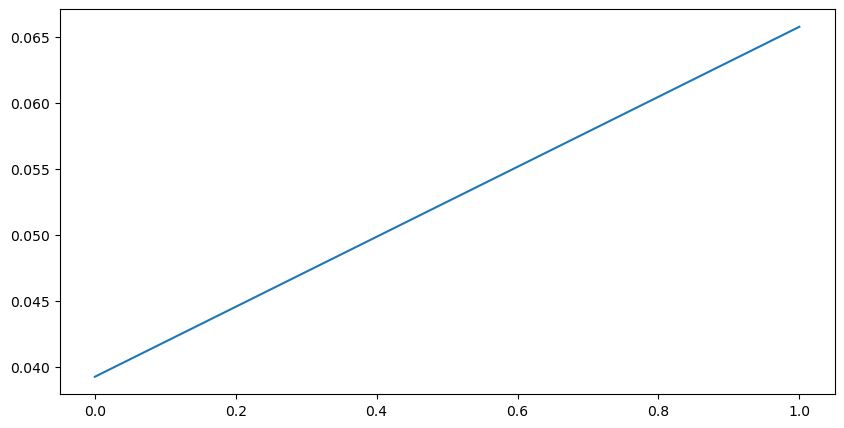

In [94]:
# plot training and validation accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

In [95]:
# Next word prediction
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted)
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
        
seed_text = "to be or not to"
next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
print(f'Next word prediction for "{seed_text}": {next_word}')   


Next word prediction for "to be or not to": the
